(https://github.com/sihsieh65-tech/cs82a-portfolio/tree/main/Module5)

Loading libraries and dataset. I then did a quick info diagnostic then checked for NA data. 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df= pd.read_csv("custdata.tsv", sep="\t")
df

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida
...,...,...,...,...,...,...,...,...,...,...,...
995,1411132,F,False,46000,Divorced/Separated,True,Rented,True,1.0,56.0,Florida
996,1411860,F,NaN,5400,Widowed,True,NaN,NaN,NaN,89.0,Pennsylvania
997,1412161,M,True,38500,Married,True,Rented,True,1.0,29.0,Georgia
998,1412971,M,NaN,43400,Married,True,Homeowner free and clear,False,1.0,88.0,Ohio


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   custid        1000 non-null   int64  
 1   sex           1000 non-null   str    
 2   is.employed   672 non-null    object 
 3   income        1000 non-null   int64  
 4   marital.stat  1000 non-null   str    
 5   health.ins    1000 non-null   bool   
 6   housing.type  944 non-null    str    
 7   recent.move   944 non-null    object 
 8   num.vehicles  944 non-null    float64
 9   age           1000 non-null   float64
 10  state.of.res  1000 non-null   str    
dtypes: bool(1), float64(2), int64(2), object(2), str(4)
memory usage: 79.2+ KB


In [3]:
df.isna().sum()

custid            0
sex               0
is.employed     328
income            0
marital.stat      0
health.ins        0
housing.type     56
recent.move      56
num.vehicles     56
age               0
state.of.res      0
dtype: int64

Dropped rows containing NA data under the housing.type column. This removed 56 rows of data.  

In [4]:
df_cleaned = df.dropna(subset=['housing.type'])
df_cleaned

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida
...,...,...,...,...,...,...,...,...,...,...,...
994,1409249,M,NaN,36200,Married,True,Homeowner free and clear,False,5.0,73.0,New York
995,1411132,F,False,46000,Divorced/Separated,True,Rented,True,1.0,56.0,Florida
997,1412161,M,True,38500,Married,True,Rented,True,1.0,29.0,Georgia
998,1412971,M,NaN,43400,Married,True,Homeowner free and clear,False,1.0,88.0,Ohio


A quick to ensure all NA data was removed from the housing.type column.

In [5]:
df_cleaned.isna().sum()

custid            0
sex               0
is.employed     280
income            0
marital.stat      0
health.ins        0
housing.type      0
recent.move       0
num.vehicles      0
age               0
state.of.res      0
dtype: int64

I then wanted to group the data by housing.type and count the rows of each category. This will give me some idea of what to expect in the bar chart. 

In [6]:
df_cleaned.groupby("housing.type").size().reset_index(name="row_count").sort_values(by="row_count", ascending=True)


,housing.type,row_count
2,Occupied with no rent,11
0,Homeowner free and clear,157
3,Rented,364
1,Homeowner with mortgage/loan,412


Plotted the data in a bar chart

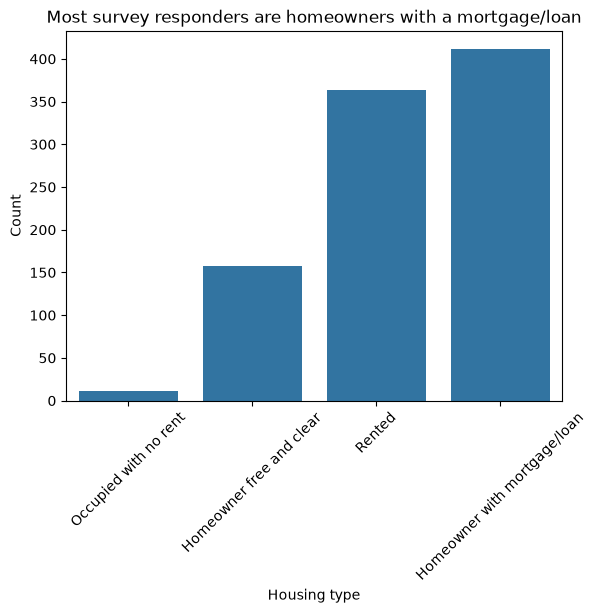

In [7]:
df_sorted = df_cleaned.groupby("housing.type").size().reset_index(name="row_count").sort_values(by="row_count", ascending=True)
sns.barplot(x="housing.type",y="row_count",data=df_sorted)
plt.title("Most survey responders are homeowners with a mortgage/loan")
plt.xlabel("Housing type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()